# Linear Regression

- y = 우리가 예측하고 싶은 값 (기대수명, 정답)
- X = 그 정답을 설명하는 숫자 정보들

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [11]:
# 1) 데이터 로드
df = pd.read_csv('./data/cleaned_disease_data.csv')

df

,Country,Year,Status,Life_expectancy,Alcohol,Hepatitis_B,BMI,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Region_encoded,Schooling,Measles
0,Afghanistan,2000,0,54.8,0.01,62.0,12.2,24.0,24.0,0.1,114.560000,2.3,2.5,AFG,Asia,1,1.264052,27.0
1,Afghanistan,2001,0,55.3,0.01,63.0,12.6,35.0,33.0,0.1,117.496980,2.1,2.4,AFG,Asia,1,1.315551,37.0
2,Afghanistan,2002,0,56.2,0.01,64.0,13.0,36.0,36.0,0.1,187.845950,19.9,2.2,AFG,Asia,1,1.367049,35.0
3,Afghanistan,2003,0,56.7,0.01,65.0,13.4,41.0,41.0,0.1,198.728544,19.7,19.9,AFG,Asia,1,1.418548,39.0
4,Afghanistan,2004,0,57.0,0.02,95.0,13.8,95.0,95.0,0.1,219.141353,19.5,19.7,AFG,Asia,1,1.470046,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2761,Zimbabwe,2011,0,54.9,6.00,94.0,29.9,93.0,93.0,13.3,839.927936,6.8,6.7,ZWE,Africa,0,7.768000,92.0
2762,Zimbabwe,2012,0,56.6,6.09,97.0,3.3,95.0,95.0,8.8,955.648466,6.5,6.4,ZWE,Africa,0,7.870000,97.0
2763,Zimbabwe,2013,0,58.0,6.39,95.0,3.8,95.0,95.0,6.8,111.227396,6.2,6.0,ZWE,Africa,0,7.990000,93.0
2764,Zimbabwe,2014,0,59.2,6.50,91.0,31.3,92.0,91.0,6.3,127.474620,5.9,5.7,ZWE,Africa,0,8.110000,92.0


In [12]:
# 2) 타겟(y) / 피처(X) 분리
y = df['Life_expectancy']
y

0       54.8
1       55.3
2       56.2
3       56.7
4       57.0
        ... 
2761    54.9
2762    56.6
2763    58.0
2764    59.2
2765    67.0
Name: Life_expectancy, Length: 2766, dtype: float64

In [31]:
# 문자열 컬럼은 제거 
drop_cols = ['Life_expectancy', 'Country', 'Iso_code', 'Region', 'HIV_AIDS', 'Year']
X = df.drop(columns=drop_cols)

In [32]:
# 혹시 결측치 
print("결측치 개수:\n", X.isna().sum().sort_values(ascending=False).head(10))

결측치 개수:
 Status                  0
Alcohol                 0
Hepatitis_B             0
BMI                     0
Polio                   0
Diphtheria              0
GDP                     0
thinness _1_19_years    0
thinness_5_9_years      0
Region_encoded          0
dtype: int64


In [33]:
# 학습/평가 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("사용 :", list(X.columns))

X_train: (2212, 12) X_test: (554, 12)
사용 : ['Status', 'Alcohol', 'Hepatitis_B', 'BMI', 'Polio', 'Diphtheria', 'GDP', 'thinness _1_19_years', 'thinness_5_9_years', 'Region_encoded', 'Schooling', 'Measles']


In [34]:
# fit 평균, 표준편차 계산 / train 기준
# transform 이미 계산된 평균 / 표준편차로 변환만

In [35]:
# 스케일링

scaler = StandardScaler()

# train 데이터로 기준 학습 + 변환
X_train_sc = scaler.fit_transform(X_train)

# test 데이터는 변환만 
X_test_sc = scaler.transform(X_test)

print("스케일링 전:")
print(X_train.head())

print("\n스케일링 후 (일부):")
print(X_train_sc[:5])

스케일링 전:
      Status  Alcohol  Hepatitis_B   BMI  Polio  Diphtheria          GDP  \
2124       1     8.51         99.0  54.4   97.0        97.0  5828.745662   
2715       0     0.04         73.0  39.6   67.0        73.0  1378.750030   
2231       0     4.21         87.0  17.5   38.0        38.0   227.779471   
261        0     1.93         99.0   6.1   99.0        99.0  2722.138900   
2059       1     9.50         98.0  55.5   99.0        99.0   821.251569   

      thinness _1_19_years  thinness_5_9_years  Region_encoded  Schooling  \
2124                   3.2                 3.7               2  10.408000   
2715                  13.7                13.5               1   3.565477   
2231                   1.1                 1.2               0   2.865069   
261                    6.0                 5.9               1   8.030000   
2059                   2.3                 2.5               2  11.810000   

      Measles  
2124     95.0  
2715     68.0  
2231     50.0  
261     

In [36]:
# 모델 생성
# 스케일링 지표들을 보고 기대수명을 가장 잘 설명하는 직선 찾기

lr = LinearRegression()

# 학습 
# 이 나리들은 이런 조건일 때 이런 기대수명이었다, 이 데이터들을 가장 잘 설명하는 공식 찾아줘라
lr.fit(X_train_sc, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


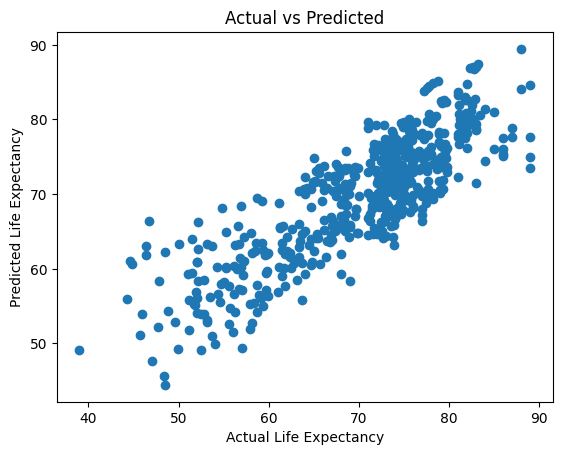

In [37]:
# 실제값 VS 예측값 산점도
# 모델이 예측한 기대수명이 실제 기대수명과 얼마나 비슷한지 보는 그래프
# 점 하나 = 실제 기대수명 70, 모델 예측 72

import matplotlib.pyplot as plt

y_pred = lr.predict(X_test_sc)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted")
plt.show()


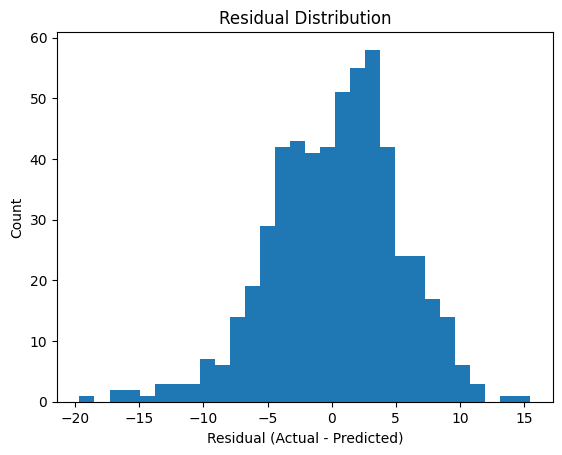

In [38]:
# 잔차 분포
# 모델이 예측한 기대수명이 실제값과 얼마나 차이가 있는지 분포

# residual = 실제값 - 예측값
residuals = y_test - y_pred

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()


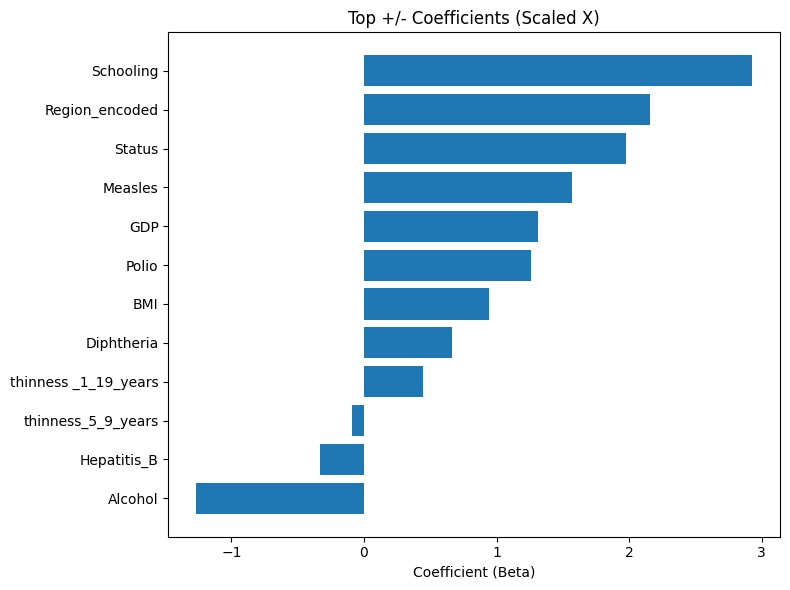

In [39]:
# 회귀계수 상위 / 하위 차트
# 어떤 지표가 기대수명을 얼마나 올리는지, 얼마나 떨어뜨리는지 확인

# 위에있을 수록 영향력 큼, 막대가 길수록
# 오른쪽 = 기대수명 증가 요인
# 왼쪽 = 기대수명 감소 요인

coef = pd.Series(lr.coef_, index=X.columns).sort_values()

# 영향 큰 것 위/아래 10개만 보기
top = pd.concat([coef.head(10), coef.tail(10)])

plt.figure(figsize=(8, 6))
plt.barh(top.index, top.values)
plt.xlabel("Coefficient (Beta)")
plt.title("Top +/- Coefficients (Scaled X)")
plt.tight_layout()
plt.show()


In [40]:
# 기대수명을 평균적으로 약 3~4년 오차로 전체 변동의 약 80프로를 설명한다.

# 예측
y_pred = lr.predict(X_test_sc)

# 평가
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.3f}")


RMSE : 5.08
MAE  : 4.02
R²   : 0.707


1. RMSE 
: MSE애 루트 씌워서 에러를 제곱해 생기는 값의 왜곡이 줄어든다 -> 값이 낮을 수록 좋다
- 오차를 제곱 -> 평균 -> 루트
- 큰 실수를 더 세게 벌주는 지표


2. MAE 
: 실제 정답 값과 예측 값의 차이를 절댓값으로 변환한 뒤 합산하여 평균을 구한다. -> 값이 낮을 수록 좋음
- |실제 - 예측|의 평균
- 사람이 이해하기 쉬운 오차

3. R²
- 1, 2번의 지표들은 모델마다 값이 다르기 때문에 절댓값만 보고 성능 판단어렵
- 실제값의 분산 대비 예측값의 분산 비율을 의미 1에 가까울 수록 좋음


In [25]:
# 회귀계수 추출
# 각 지표가 기대수명에 얼마나 영향을 주는지를 숫자(회귀계수)로 정리한 표

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Beta': lr.coef_
}).sort_values(by='Beta', ascending=False)

coef_df


,Feature,Beta
12,Schooling,2.745126
1,Status,1.525019
11,Region_encoded,1.368023
8,GDP,1.194344
13,Measles,1.178372
5,Polio,0.997018
6,Diphtheria,0.798772
4,BMI,0.764045
9,thinness _1_19_years,0.335936
0,Year,0.168663


-- 평가지표 성능확인까지

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_regression(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2score: {r2:.4f}")


In [ ]:
# Ridge (기본 + 평가)

from sklearn.linear_model import Ridge

reg_l2 = Ridge()  
reg_l2.fit(X_train_sc, y_train)

print(reg_l2.score(X_train_sc, y_train), reg_l2.score(X_test_sc, y_test))
evaluate_regression(y_test, reg_l2.predict(X_test_sc))


0.704168081485369 0.7068690299033806
MSE: 25.7792 | RMSE: 5.0773 | MAE: 4.0199 | R2score: 0.7069


0.7041681882193379 0.7068563693467906
0.7041681871592305 0.7068575305334264
0.704168081485369 0.7068690299033806
0.7041578358656946 0.7069731111831556
0.7033618808143991 0.7071666559743142


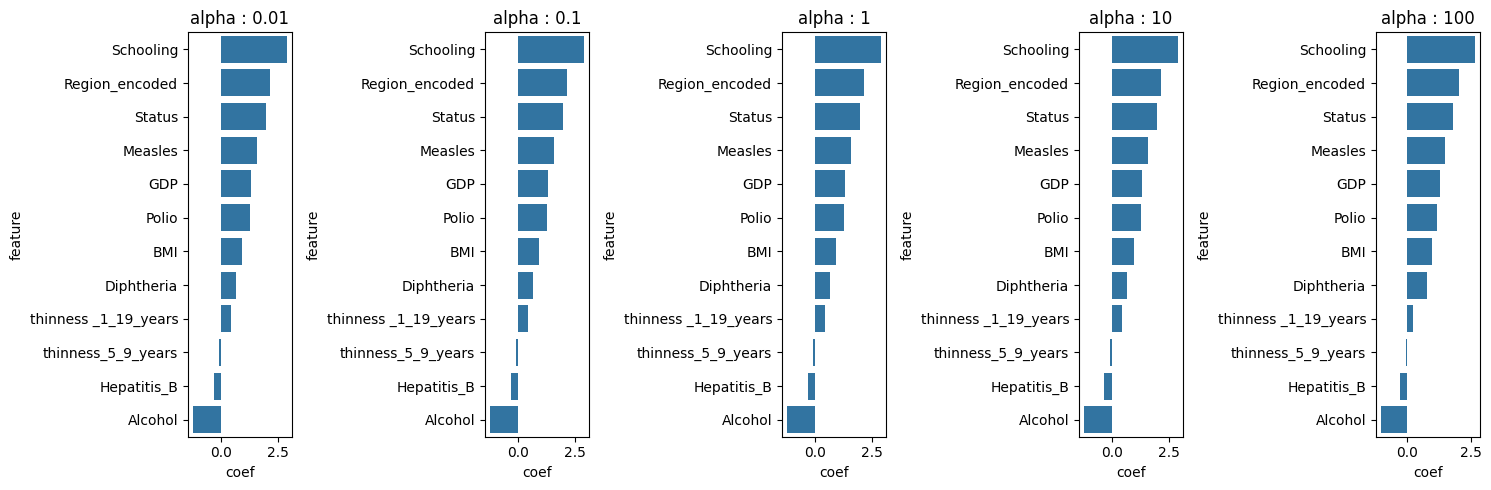

In [ ]:
# Ridge : alpha 값에 따른 계수 시각화

from sklearn.pipeline import Pipeline

alphas = [0.01, 0.1, 1, 10, 100]

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15, 5))

for i, alpha in enumerate(alphas):
    model = Pipeline([
        ('reg', Ridge(alpha=alpha))
    ])
    model.fit(X_train_sc, y_train)

    print(model.score(X_train_sc, y_train), model.score(X_test_sc, y_test))

    coef = model.named_steps['reg'].coef_
    coef_ser = pd.Series(coef, index=X.columns)
    coef_ser.name = 'alpha : ' + str(alpha)
    coef_ser = coef_ser.sort_values(ascending=False)

    ax[i].set_title(coef_ser.name)
    ax[i].set_xlabel('coef')
    ax[i].set_ylabel('feature')

    sns.barplot(x=coef_ser.values, y=coef_ser.index, ax=ax[i])

plt.tight_layout()
plt.show()


In [ ]:
# Lasso 

from sklearn.linear_model import Lasso

reg_l1 = Lasso(alpha=1, max_iter=5000)
reg_l1.fit(X_train_sc, y_train)

print(reg_l1.score(X_train_sc, y_train), reg_l1.score(X_test_sc, y_test))
print(reg_l1.coef_)
evaluate_regression(y_test, reg_l1.predict(X_test_sc))


0.6643552819645853 0.6712737012164005
[ 0.82445706  0.          0.          0.6249072   0.84129222  0.33844731
  0.78021456 -0.         -0.          1.20553413  2.64981021  1.52473444]
MSE: 28.9096 | RMSE: 5.3768 | MAE: 4.1606 | R2score: 0.6713


0.704135079409047 0.7071432481800355
0.7020792846739989 0.7073352458058042
0.6643552819645853 0.6712737012164005
0.0 -0.005190958520353117
0.0 -0.005190958520353117


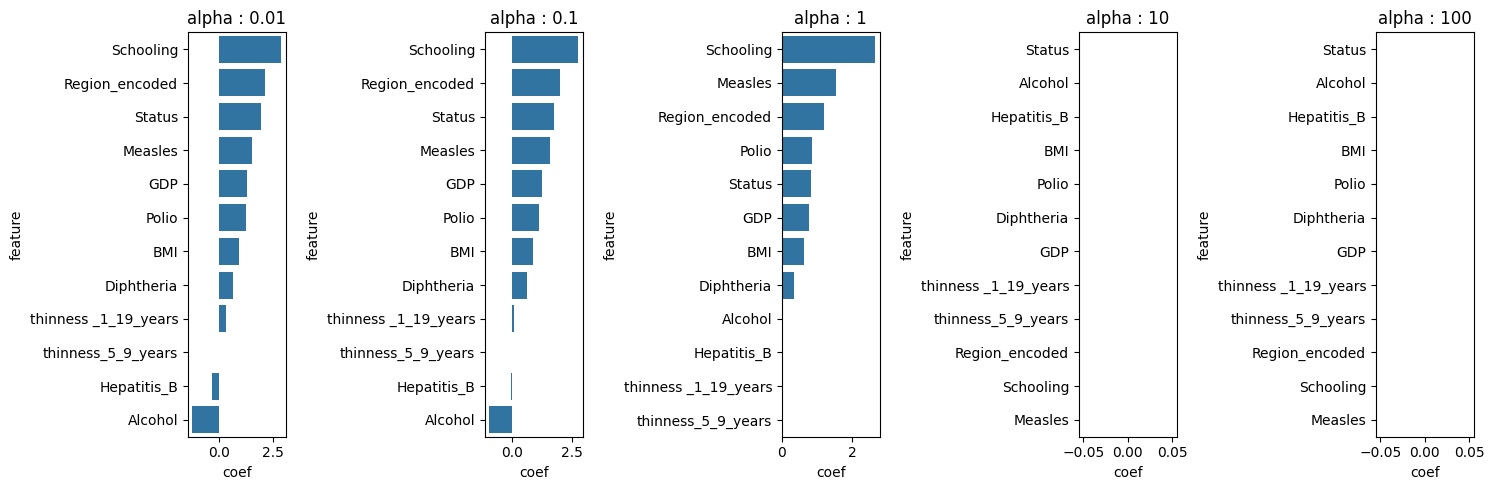

In [62]:
# Lasso : alpha 값에 따른 시각화

alphas = [0.01, 0.1, 1, 10, 100]

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15, 5))

for i, alpha in enumerate(alphas):
    model = Pipeline([
        ('reg', Lasso(alpha=alpha, max_iter=5000))
    ])
    model.fit(X_train_sc, y_train)

    print(model.score(X_train_sc, y_train), model.score(X_test_sc, y_test))

    coef = model.named_steps['reg'].coef_
    coef_ser = pd.Series(coef, index=X.columns)
    coef_ser.name = 'alpha : ' + str(alpha)
    coef_ser = coef_ser.sort_values(ascending=False)

    ax[i].set_title(coef_ser.name)
    ax[i].set_xlabel('coef')
    ax[i].set_ylabel('feature')

    sns.barplot(x=coef_ser.values, y=coef_ser.index, ax=ax[i])

plt.tight_layout()
plt.show()


In [ ]:
# ElasticNet 

from sklearn.linear_model import ElasticNet

reg_ela = ElasticNet(alpha=1, l1_ratio=0.5, max_iter=5000) 
reg_ela.fit(X_train_sc, y_train)

print(reg_ela.score(X_train_sc, y_train), reg_ela.score(X_test_sc, y_test))
print(reg_ela.coef_)
evaluate_regression(y_test, reg_ela.predict(X_test_sc))

0.6604965055993135 0.6668584563345965
[ 0.97928745  0.          0.          0.89576211  0.94135597  0.85050251
  0.93124938 -0.13352466 -0.17222228  1.16369522  1.72061182  1.16770914]
MSE: 29.2979 | RMSE: 5.4128 | MAE: 4.1922 | R2score: 0.6669


0.7041285068552466 0.7071306520331717
0.7017269199890485 0.706773566100693
0.6604965055993135 0.6668584563345965
0.07442236169590943 0.07049237549681076
0.0 -0.005190958520353117


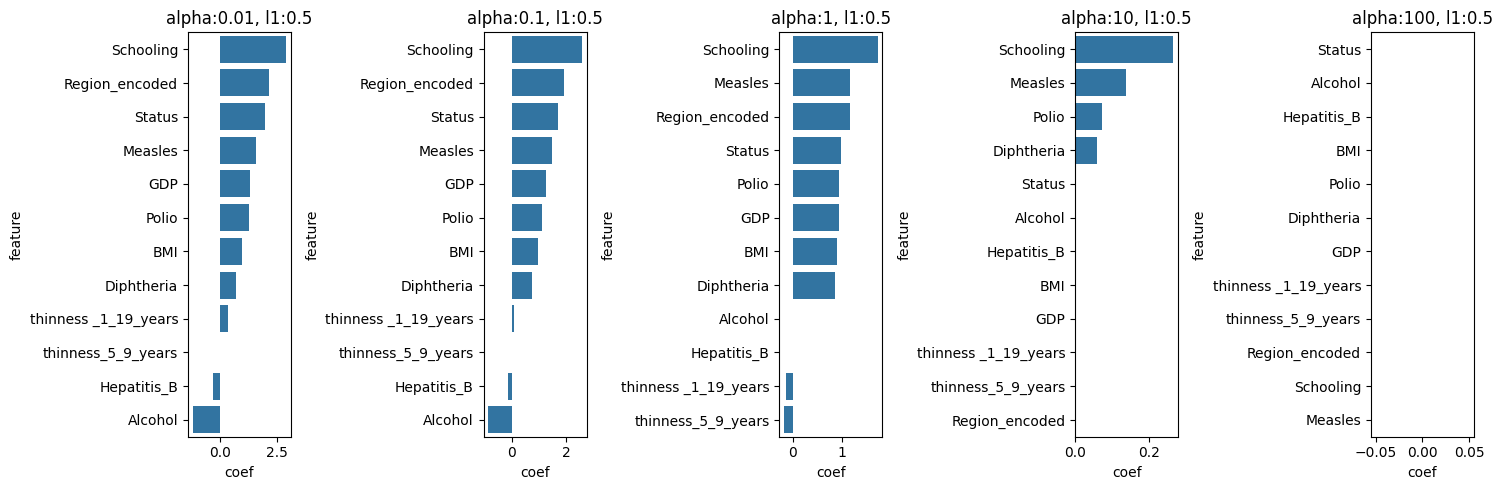

In [ ]:
# ElasticNet 시각화

alphas = [0.01, 0.1, 1, 10, 100]
l1_ratio = 0.5 

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15, 5))

for i, alpha in enumerate(alphas):
    model = Pipeline([
        ('reg', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000))
    ])
    model.fit(X_train_sc, y_train)

    print(model.score(X_train_sc, y_train), model.score(X_test_sc, y_test))

    coef = model.named_steps['reg'].coef_
    coef_ser = pd.Series(coef, index=X.columns)
    coef_ser.name = f'alpha:{alpha}, l1:{l1_ratio}'
    coef_ser = coef_ser.sort_values(ascending=False)

    ax[i].set_title(coef_ser.name)
    ax[i].set_xlabel('coef')
    ax[i].set_ylabel('feature')

    sns.barplot(x=coef_ser.values, y=coef_ser.index, ax=ax[i])

plt.tight_layout()
plt.show()


---

##### 내가 좀 보기 쉽도록 해논 코드 (위에랑 같음 !! )

- Ridge : 모든 변수를 조금씩 쓰되, 너무 세게 쓰지 않게 함
- Lasso : 쓸모없는 변수는 아예 0으로 만들어버림
- ElasticNet : Ridge + Lasso

- 공통 핵심 : 하이퍼파라미터 = alpha, 얼마나 강하게 제약할거냐
alpha 높으면 -> 제약 강하고, 계수가 작아짐
alpha 낮으면 -> 원래 선형회귀랑 비슷

-> alpha를 바꿔보는게 하이퍼 파라미터 튜닝

Ridge Regression L2
- 다 쓰긴 쓸껀데 너무 튀는 가중치는 억제하자 !

In [ ]:
# 작을수록 -> 기본 선형회귀랑 비슷
# 클수록 -> 계수 억제(보수적)

from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_sc, y_train)
    r2 = ridge.score(X_test_sc, y_test)
    ridge_results.append((a, r2))

ridge_results


[(0.01, 0.7068563693467906),
 (0.1, 0.7068575305334264),
 (1, 0.7068690299033806),
 (10, 0.7069731111831556),
 (100, 0.7071666559743142)]

In [ ]:
# 결과 -> 특정 alpha에 과하게 의존 X
# 과적합 가능성 낮음

Lasso Regression (L1)
- 중요하지 않은 변수는 아예 제거
- 계수 = 0이 나오는 변수가 생김
- 변수 선택 효과 있음
-> alpha가 커질수록 몇 개 변수가 제거되었다.

In [54]:
from sklearn.linear_model import Lasso

lasso_results = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train_sc, y_train)
    r2 = lasso.score(X_test_sc, y_test)
    zero_cnt = (lasso.coef_ == 0).sum()
    lasso_results.append((a, r2, zero_cnt))

lasso_results


[(0.01, 0.7071432481800355, np.int64(1)),
 (0.1, 0.7073352458058042, np.int64(1)),
 (1, 0.6712737012164005, np.int64(4)),
 (10, -0.005190958520353117, np.int64(12)),
 (100, -0.005190958520353117, np.int64(12))]

ElasticNet (L1 + L2)
- Ridge의 안전성 + Lasso의 변수선택

파라미터
- alpha : 전체 제약 강도
- L1_ratio : 0 -> Ridge / 1 -> Lasso

In [67]:
from sklearn.linear_model import ElasticNet

enet_results = []

for a in [0.01, 0.1, 1, 10]:
    for l1 in [0.2, 0.5, 0.8]:
        enet = ElasticNet(alpha=a, l1_ratio=l1, max_iter=5000)
        enet.fit(X_train_sc, y_train)
        r2 = enet.score(X_test_sc, y_test)
        enet_results.append((a, l1, r2))

enet_results

#(0.1, 0.8, 0.7071633548686687)


[(0.01, 0.2, 0.7071048579464085),
 (0.01, 0.5, 0.7071306520331717),
 (0.01, 0.8, 0.70714076989833),
 (0.1, 0.2, 0.7062938641476082),
 (0.1, 0.5, 0.706773566100693),
 (0.1, 0.8, 0.7071633548686687),
 (1, 0.2, 0.6624469881153695),
 (1, 0.5, 0.6668584563345965),
 (1, 0.8, 0.670973143036421),
 (10, 0.2, 0.27186740602642023),
 (10, 0.5, 0.07049237549681076),
 (10, 0.8, -0.005190958520353117)]

---

In [ ]:

# 추가 - GridSearchCV()
# train 데이터만 가지고 5번의 평균점수

from sklearn.model_selection import GridSearchCV

results = []

# Ridge
ridge_grid = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1, 10, 100]},
    scoring='r2', cv=5
)
ridge_grid.fit(X_train_sc, y_train)
results.append(('Ridge', ridge_grid.best_params_, ridge_grid.best_score_))

# Lasso
lasso_grid = GridSearchCV(
    Lasso(max_iter=5000),
    {'alpha': [0.01, 0.1, 1, 10]},
    scoring='r2', cv=5
)
lasso_grid.fit(X_train_sc, y_train)
results.append(('Lasso', lasso_grid.best_params_, lasso_grid.best_score_))

# ElasticNet
enet_grid = GridSearchCV(
    ElasticNet(max_iter=5000),
    {'alpha': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]},
    scoring='r2', cv=5
)
enet_grid.fit(X_train_sc, y_train)
results.append(('ElasticNet', enet_grid.best_params_, enet_grid.best_score_))

pd.DataFrame(results, columns=['Model', 'Best Params', 'Best CV R2'])



,Model,Best Params,Best CV R2
0,Ridge,{'alpha': 10},0.700528
1,Lasso,{'alpha': 0.01},0.700574
2,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.8}",0.700562


In [ ]:
# 최고를 뽑아서 test 에 넣어본 점수 !

models = {
    "Ridge": ridge_grid.best_estimator_,
    "Lasso": lasso_grid.best_estimator_,
    "ElasticNet": enet_grid.best_estimator_
}

for name, model in models.items():
    r2 = model.score(X_test_sc, y_test)
    print(name, "Test R2:", r2)


Ridge Test R2: 0.7069731111831556
Lasso Test R2: 0.7071432481800355
ElasticNet Test R2: 0.70714076989833
